In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [187]:
import os
os.makedirs("charts", exist_ok=True)

# 1. Load the Data

In [188]:
f = pd.read_csv("data/data.csv")

# 2. Review the Data Structure

In [189]:
f.shape

(6819, 96)

We have over 6819 comapny to analyze with over 96 financial ratio the indicates the financial position of each company

In [190]:
f.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [191]:
f.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [192]:
f.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [193]:
f["Bankrupt?"].value_counts(normalize=True)

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

"The target variable is highly imbalanced — 96.8% of companies did not go bankrupt and only 3.2% did. We will use class_weight='balanced' to handle this during modeling."

In [194]:
f.isna().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

No missing values found across all 96 columns — no imputation required.

# 3. Explanatory Data Analysis (EDA)

## 3.1 Statistical Analysis

### 3.1.1 Distribution of Key Financial Ratios Across All Companies

In [195]:
features_to_plot = [
    ' ROA(C) before interest and depreciation before interest',
    ' Operating Gross Margin',
    ' Cash flow rate',
    ' Cash Flow Per Share',
    ' Revenue Per Share (Yuan ¥)',
    ' Current Ratio',
    ' Debt ratio %',
    ' Borrowing dependency',
    ' Cash/Current Liability',
    ' Quick Assets/Current Liability',
    ' Current Liabilities/Liability',
    ' Cash Flow to Liability',
    ' Current Liability to Current Assets',
    ' Degree of Financial Leverage (DFL)',
    ' Interest Coverage Ratio (Interest expense to EBIT)']

In [196]:
print(f['Bankrupt?'].value_counts())
print(f['Bankrupt?'].value_counts(normalize=True))

Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64


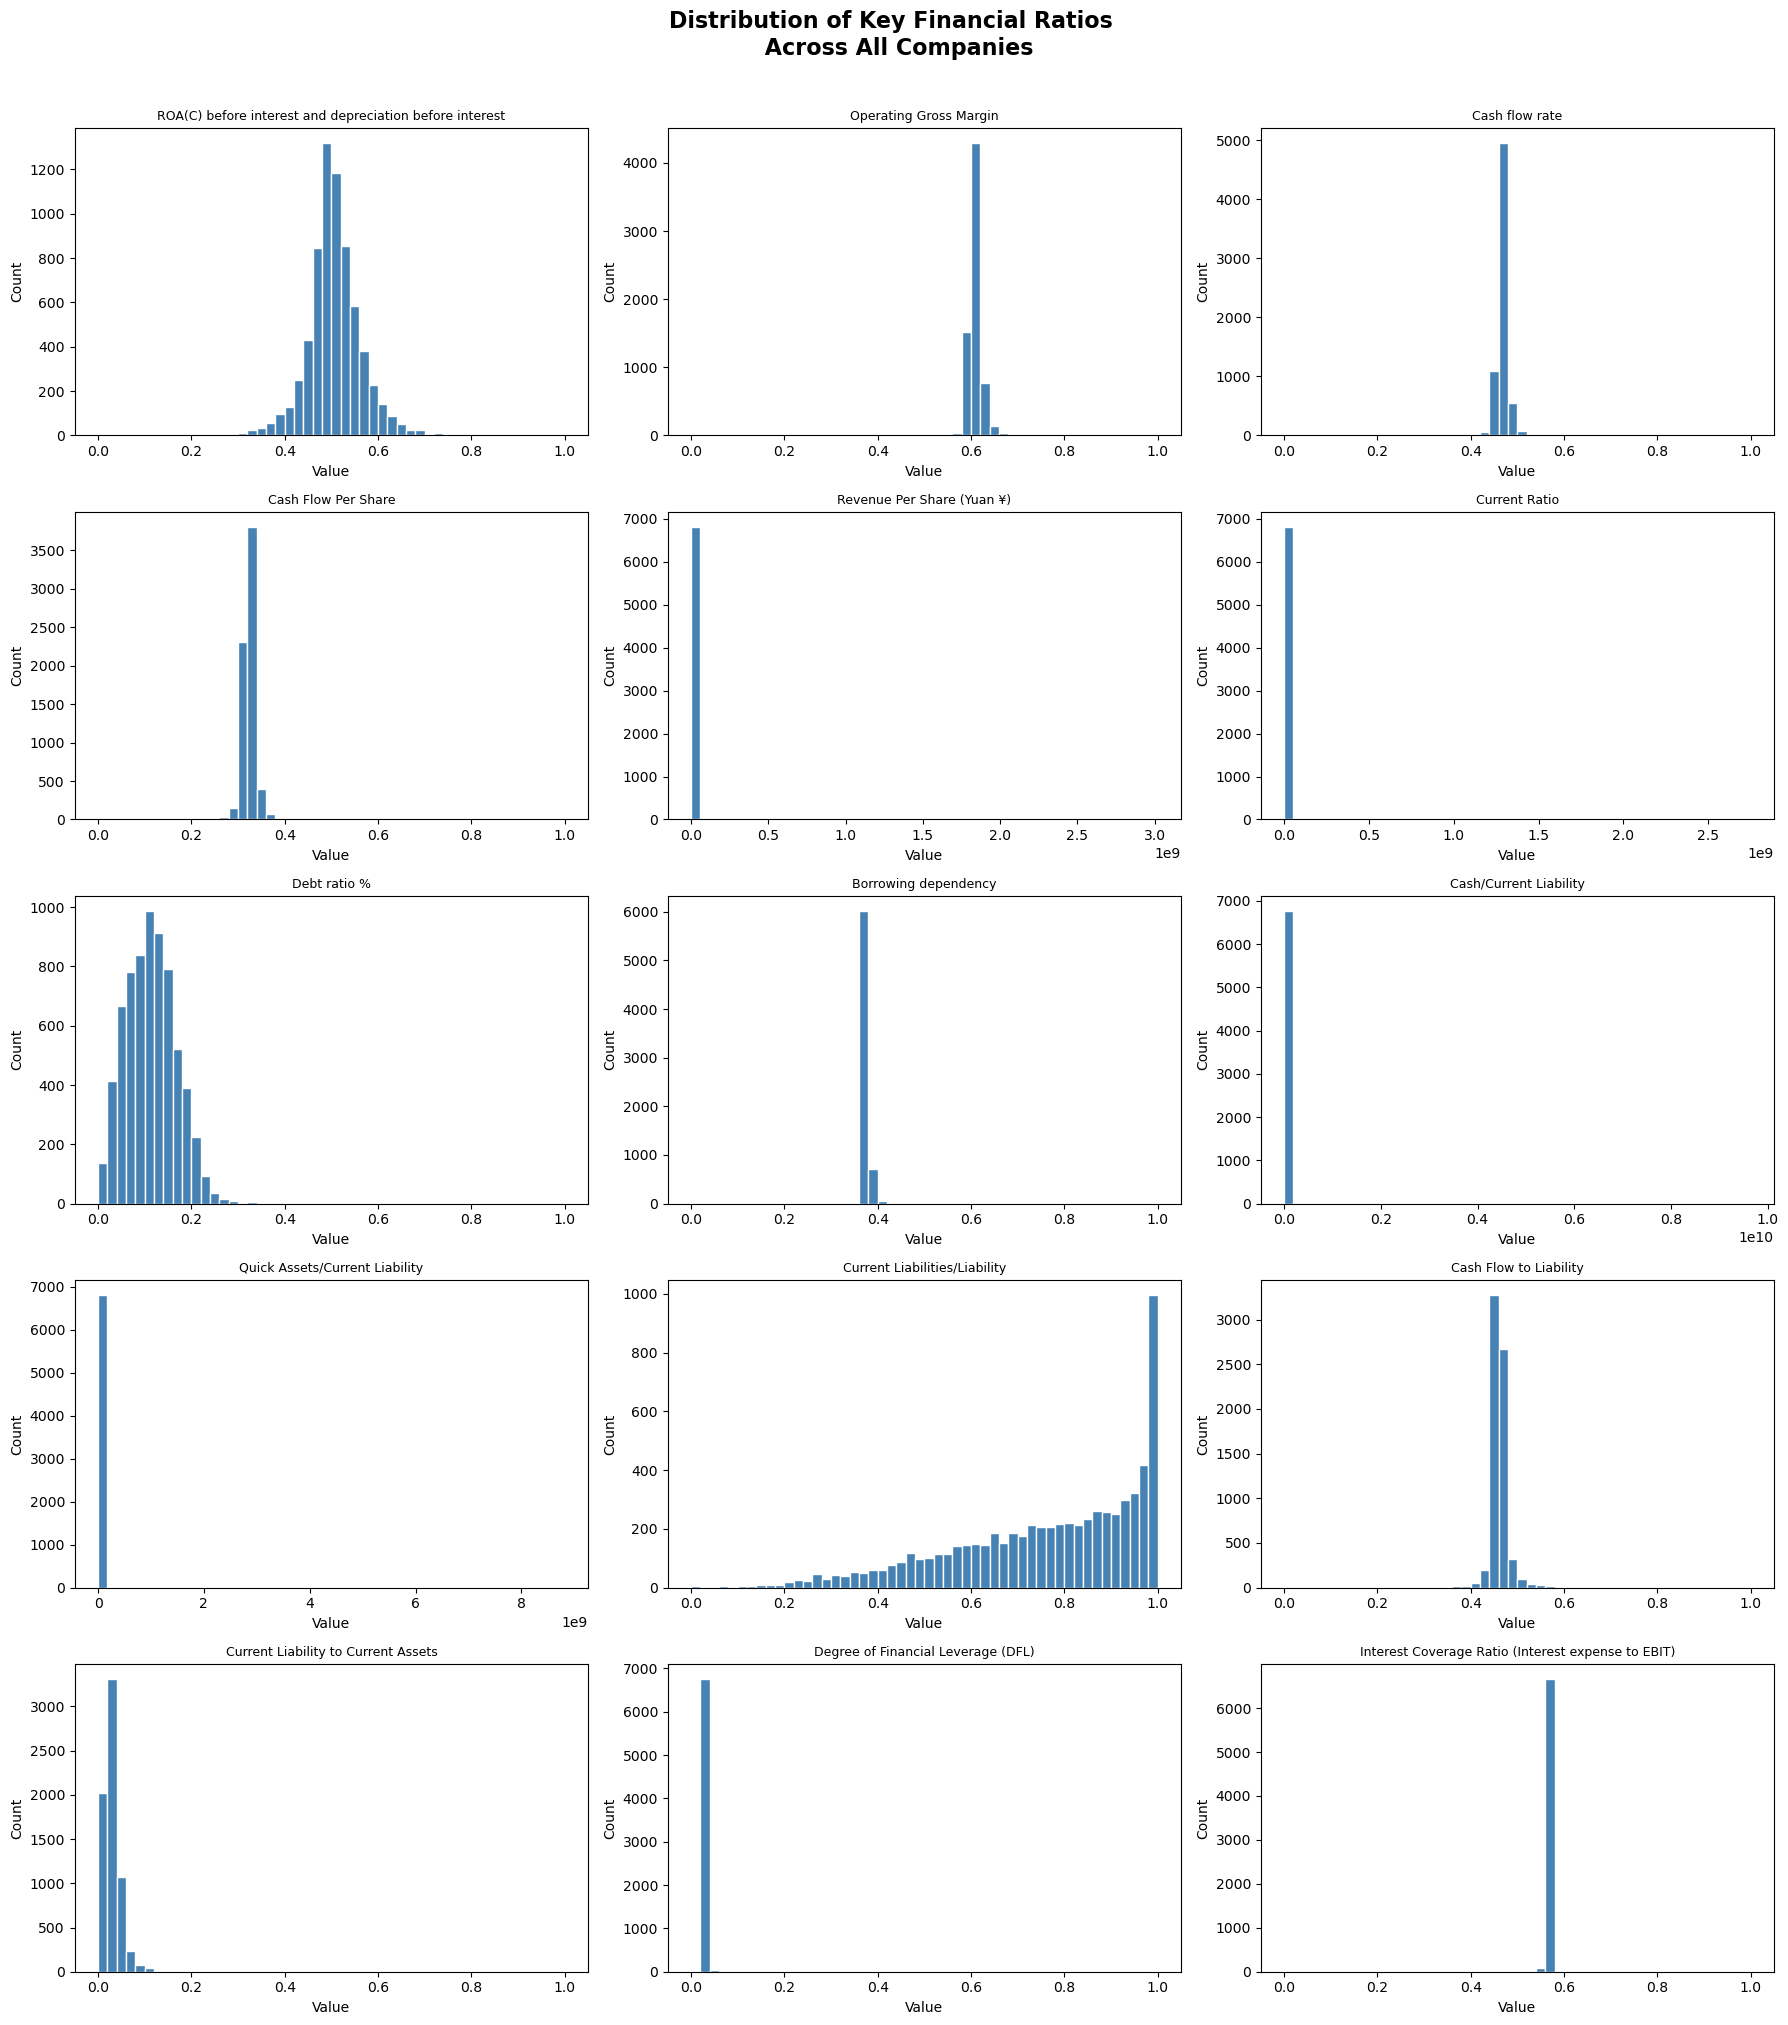

In [197]:
fig,ax = plt.subplots(5,3,figsize=(18,20))
ax = ax.flatten()
fig.suptitle('Distribution of Key Financial Ratios \n Across All Companies', fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(features_to_plot):
    ax[i].hist(f[col], bins=50, color='steelblue', edgecolor='white')
    ax[i].set_title(col.strip(), fontsize=9)
    ax[i].set_xlabel('Value')
    ax[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig("charts/01_distribution_all_companies.png", dpi=150, bbox_inches='tight')
plt.show()

### Key Observations

- **ROA(C):** Normally distributed around 0.5 — most companies have moderate profitability
- **Operating Gross Margin & Cash Flow Rate:** Highly concentrated — little variation across companies
- **Debt Ratio:** Right-skewed — most companies have low-to-moderate debt, few are highly leveraged
- **Revenue Per Share & Current Ratio:** Extreme outliers visible (x-axis reaches 1e9-2e9) — suggests a few companies have abnormally
high values
- **Current Liabilities/Liability:** Uniformly distributed — varies widely across companies
- **Borrowing Dependency & Cash/Current Liability:** Highly concentrated at one value — low variability, may be weak predictors
- **Degree of Financial Leverage & Interest Coverage Ratio:** Heavily concentrated — most companies cluster at similar values

### 3.1.2 Distribution of Key Financial Ratios For bankrupted 

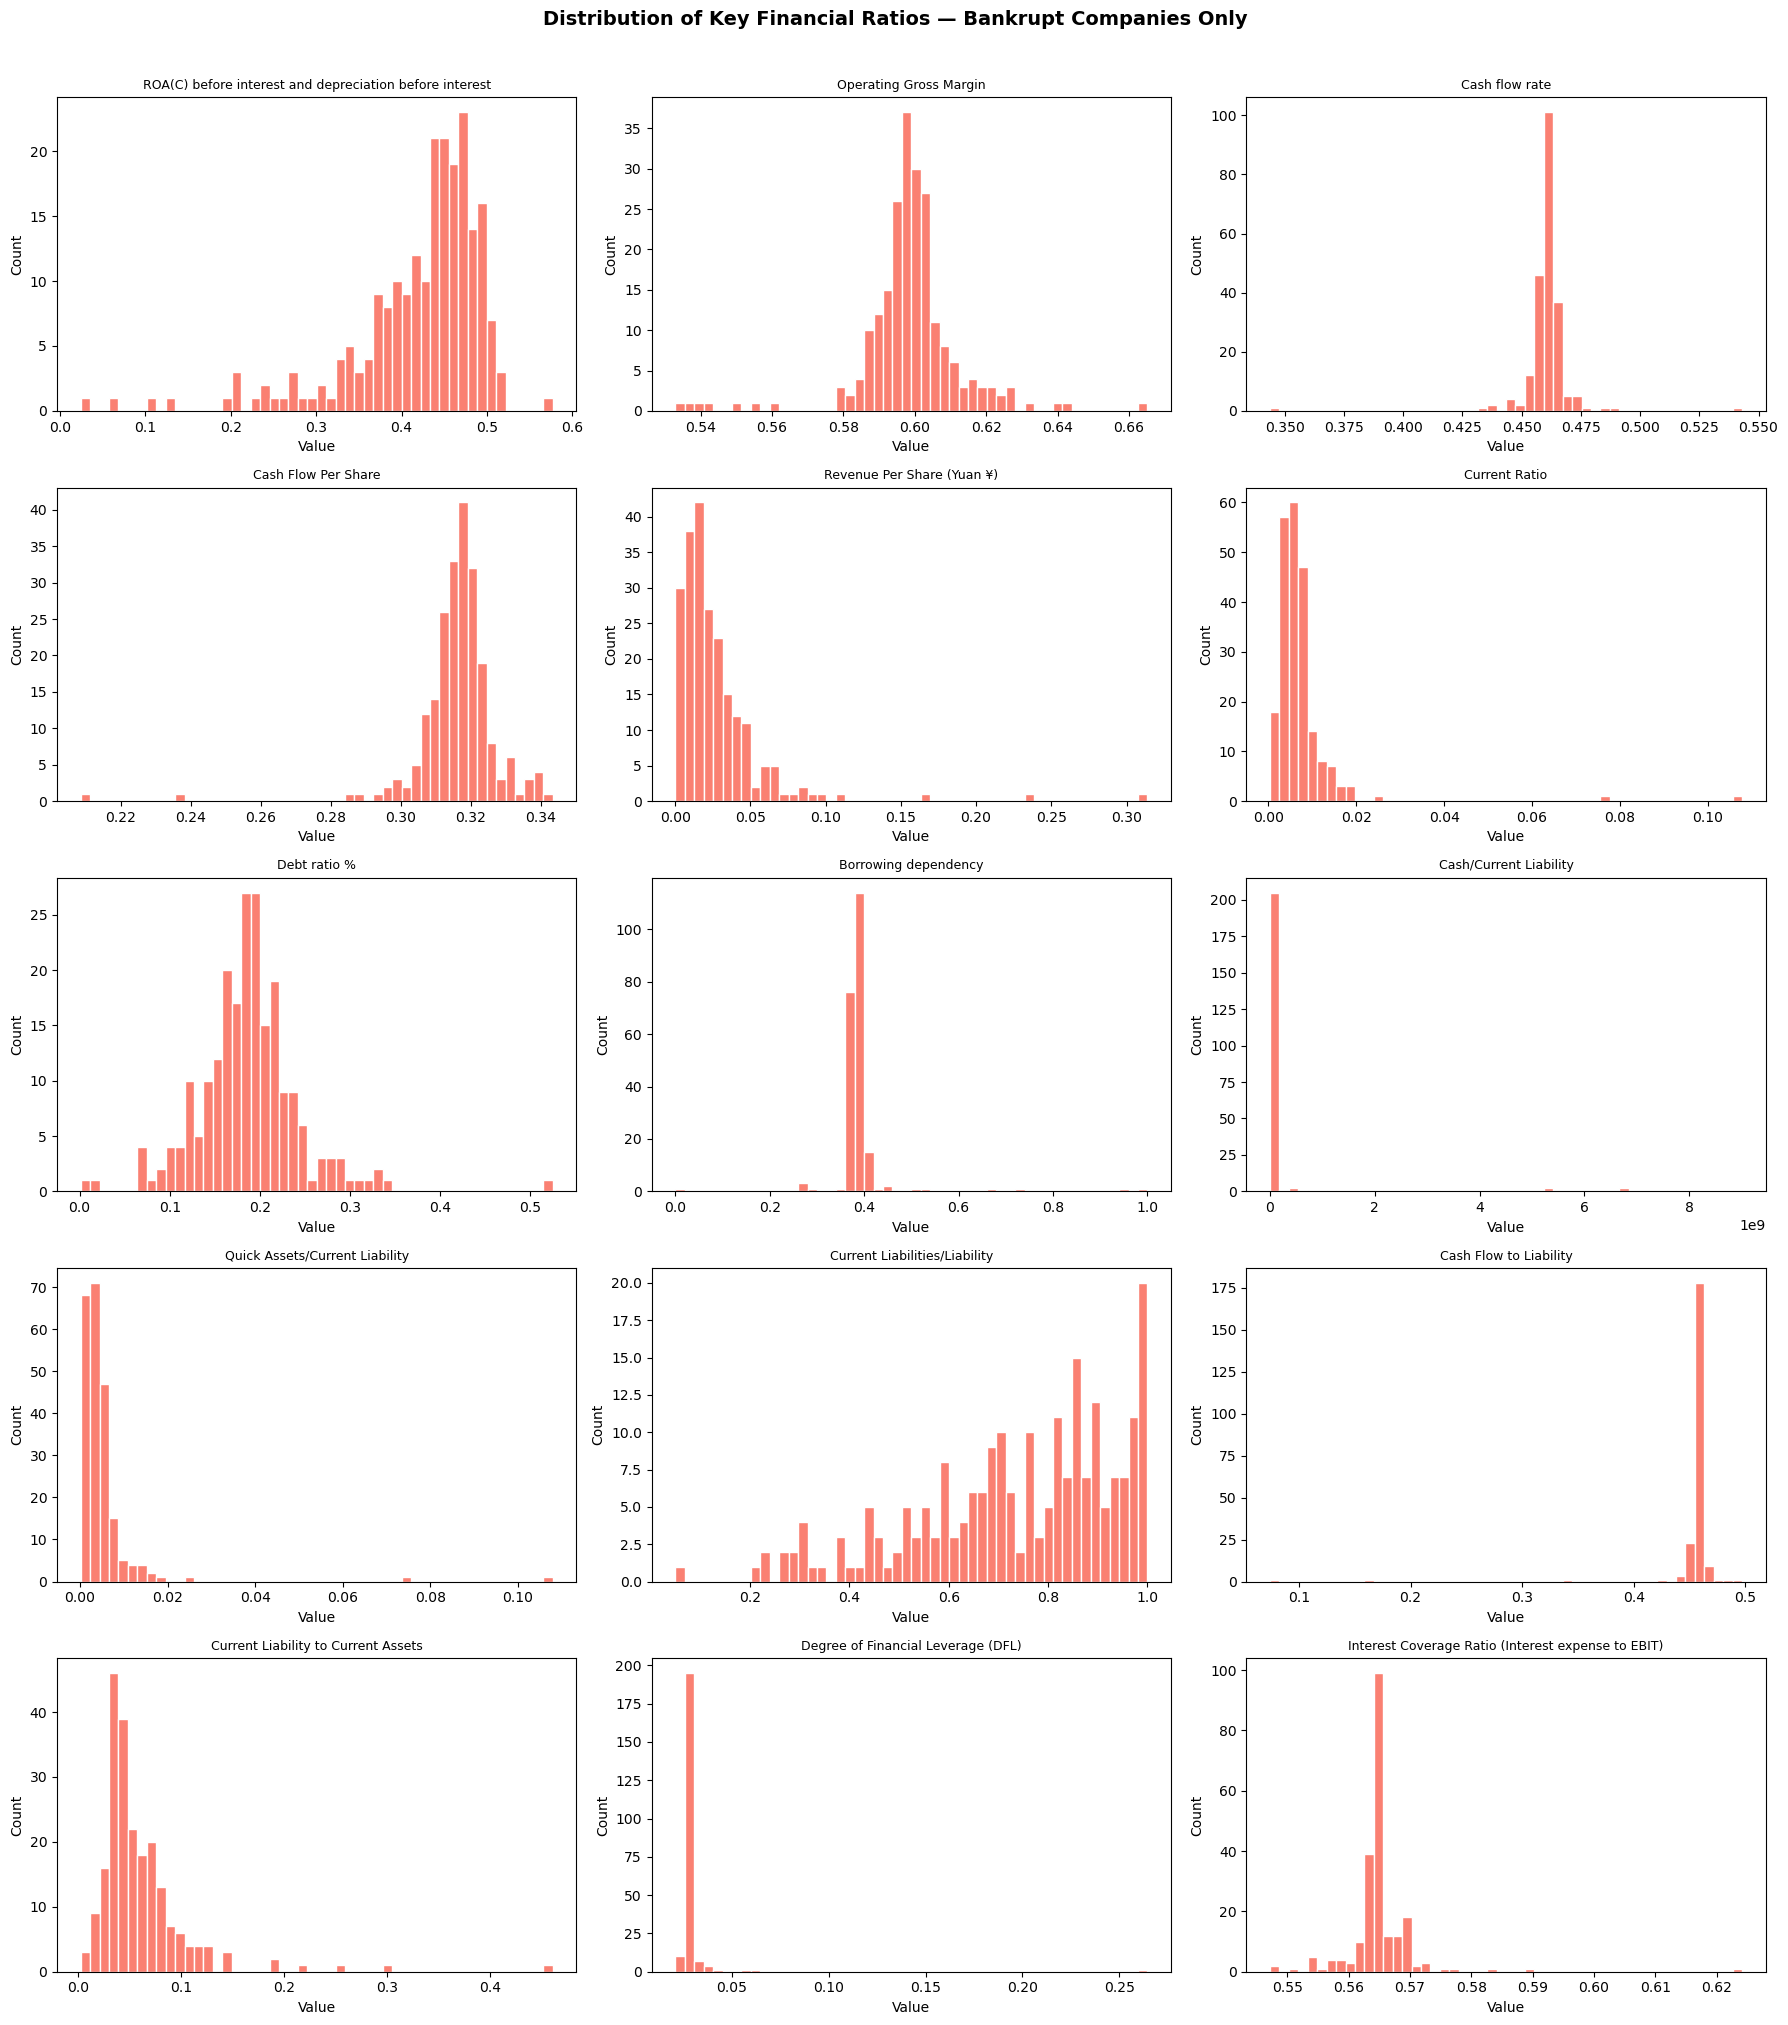

In [198]:
bankrupt = f[f['Bankrupt?'] == 1]
non_bankrupt = f[f['Bankrupt?'] == 0]

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()
fig.suptitle('Distribution of Key Financial Ratios — Bankrupt Companies Only', 
             fontsize=14, fontweight='bold', y=1.01)

for i, col in enumerate(features_to_plot):
    axes[i].hist(bankrupt[col], bins=50, color='salmon', edgecolor='white')
    axes[i].set_title(col.strip(), fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig("charts/02_bankrupt_companies_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### Key Observations — Bankrupt Companies Only

- **ROA(C):** Bankrupt companies cluster lower (0.2–0.4) indicating lower profitability compared to healthy companies
- **Revenue Per Share:** Heavily right-skewed — most bankrupt companies have very low revenue per share, clustered near 0
- **Current Ratio:** Clusters very low (near 0) — bankrupt companies cannot cover short-term obligations, a classic sign of financial distress
- **Debt Ratio:** Spread across 0–0.5 — bankrupt companies carry higher leverage than healthy peers
- **Quick Assets/Current Liability:** Clusters near 0 — bankrupt companies cannot meet immediate obligations
- **Cash/Current Liability:** Extreme outliers present — a few bankrupt companies show abnormally high cash ratios
- **Current Liabilities/Liability:** Uniformly distributed — bankrupt companies have varying liability structures
- **Degree of Financial Leverage & Interest Coverage Ratio:** Highly concentrated — most bankrupt companies cluster at similar leverage levels

### 3.1.3 Distribution of Key Financial Ratios Bankrupt vs Non-Bankrupt Companies

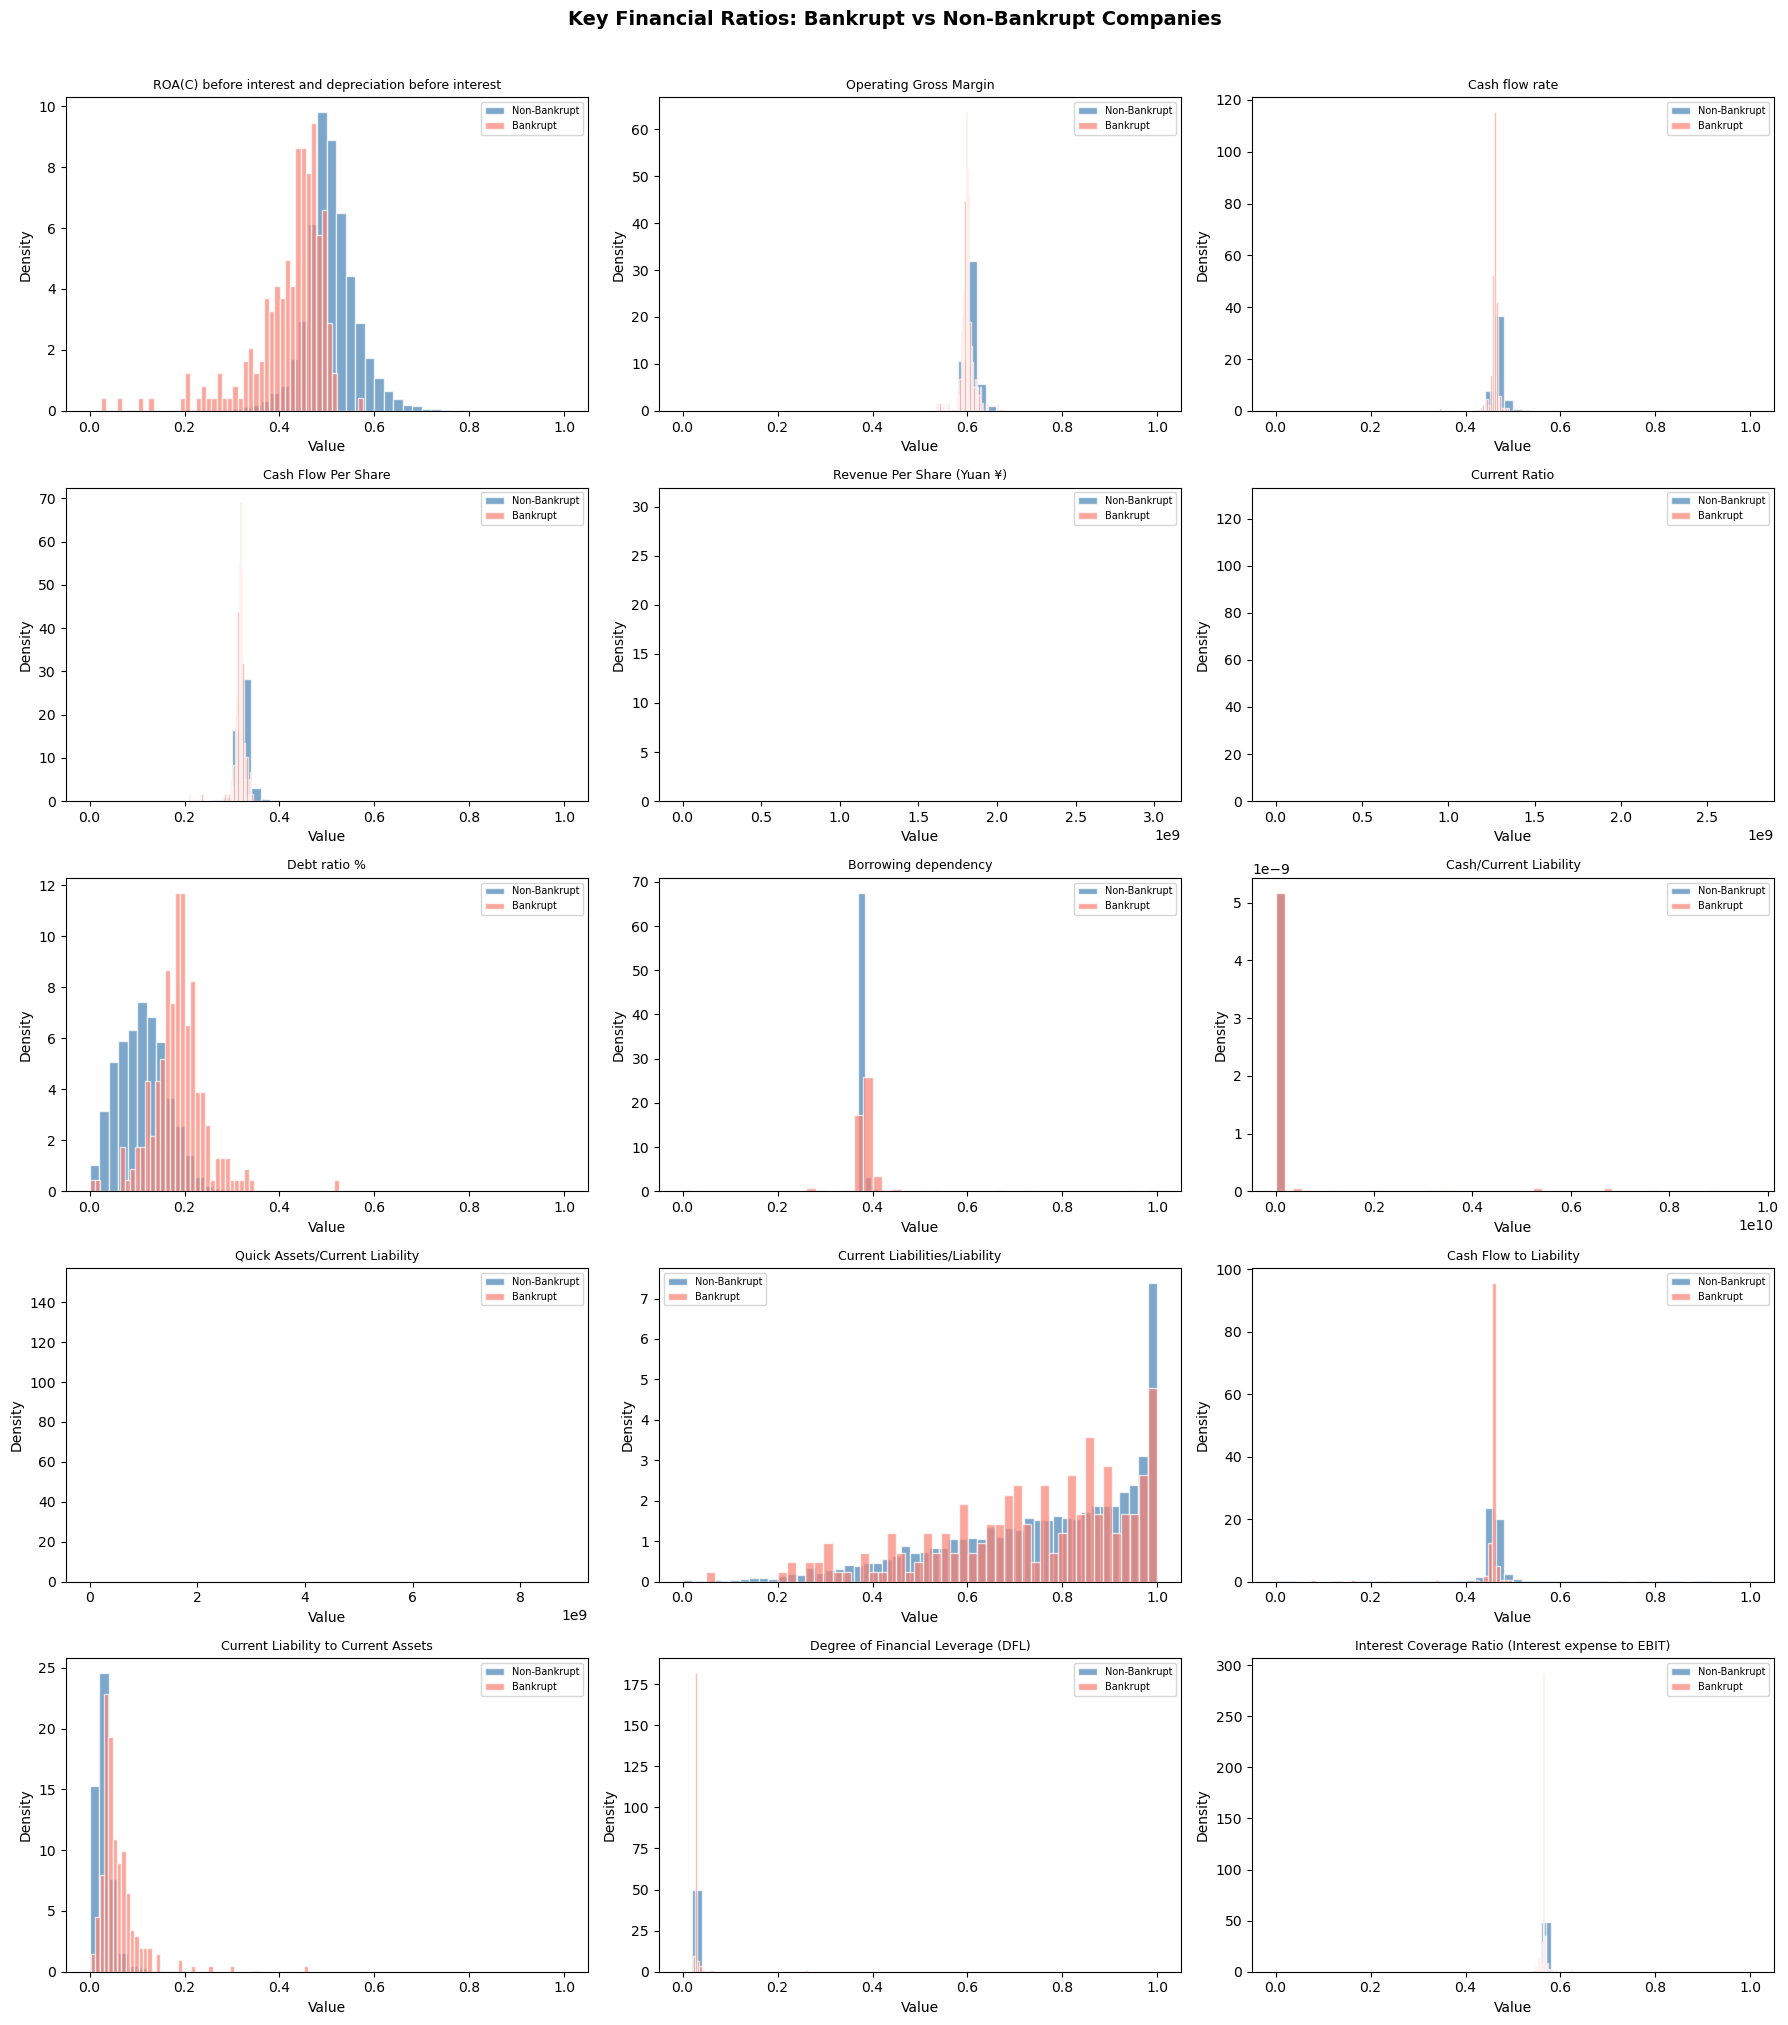

In [199]:
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()
fig.suptitle('Key Financial Ratios: Bankrupt vs Non-Bankrupt Companies', 
             fontsize=14, fontweight='bold', y=1.01)

for i, col in enumerate(features_to_plot):
    axes[i].hist(non_bankrupt[col], bins=50, color='steelblue', 
                 edgecolor='white', alpha=0.7, label='Non-Bankrupt', density=True)
    axes[i].hist(bankrupt[col], bins=50, color='salmon', 
                 edgecolor='white', alpha=0.7, label='Bankrupt', density=True)
    axes[i].set_title(col.strip(), fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.savefig("charts/02_bankrupt_vs_nonbankrupt.png", dpi=150, bbox_inches='tight')
plt.show()

### Key Observations — Bankrupt vs Non-Bankrupt Comparison

- **ROA(C):** Bankrupt companies shift left — lower return on assets indicating weaker profitability
- **Debt Ratio:** Bankrupt companies clearly skew higher — more financially leveraged than healthy peers
- **Borrowing Dependency:** Bankrupt companies spread more widely — inconsistent borrowing patterns signal financial instability
- **Current Liabilities/Liability:** Bankrupt companies concentrate at 0.8–1.0 — almost all liabilities are short-term, creating repayment pressure
- **Cash Flow to Liability:** Bankrupt companies spike near 0 — very poor cash generation relative to obligations, a strong bankruptcy signal
- **Degree of Financial Leverage:** Bankrupt companies spread widely vs non-bankrupt which concentrate — higher instability in leverage
- **Interest Coverage Ratio:** Non-bankrupt companies cluster tightly — bankrupt companies show no clear pattern, suggesting inability to service debt consistently
- **Revenue Per Share, Current Ratio, Quick Assets:** Extreme outliers stretch the x-axis making bankrupt bars invisible — these features require outlier treatment before modeling

In [200]:
corr = f.corr()['Bankrupt?'].drop('Bankrupt?').sort_values(ascending=False)

print("Top 10 features most correlated with bankruptcy:")
print(corr.head(10))
print("\nTop 10 features least correlated (negative):")
print(corr.tail(10))

Top 10 features most correlated with bankruptcy:
Debt ratio %                           0.250161
Current Liability to Assets            0.194494
Borrowing dependency                   0.176543
Current Liability to Current Assets    0.171306
Liability to Equity                    0.166812
Current Liability to Equity            0.153828
Current Liabilities/Equity             0.153828
Liability-Assets Flag                  0.139212
Total expense/Assets                   0.139049
Equity to Long-term Liability          0.139014
Name: Bankrupt?, dtype: float64

Top 10 features least correlated (negative):
Per Share Net profit before tax (Yuan ¥)                  -0.201395
Net profit before tax/Paid-in capital                     -0.207857
Retained Earnings to Total Assets                         -0.217779
Persistent EPS in the Last Four Seasons                   -0.219560
Net worth/Assets                                          -0.250161
ROA(C) before interest and depreciation before intere

## 3.2 Financial analysis Comparison

### 3.2.1 Income Ratios

In [201]:
income_ratios = [
    ' ROA(C) before interest and depreciation before interest',
    ' ROA(A) before interest and % after tax',
    ' ROA(B) before interest and depreciation after tax',
    ' Operating Gross Margin',
    ' Realized Sales Gross Margin',
    ' Operating Profit Rate',
    ' Pre-tax net Interest Rate',
    ' After-tax net Interest Rate',
    ' Revenue Per Share (Yuan ¥)',
    ' Cash Flow Per Share',
    ' Operating Profit Per Share (Yuan ¥)',
    ' Per Share Net profit before tax (Yuan ¥)',]

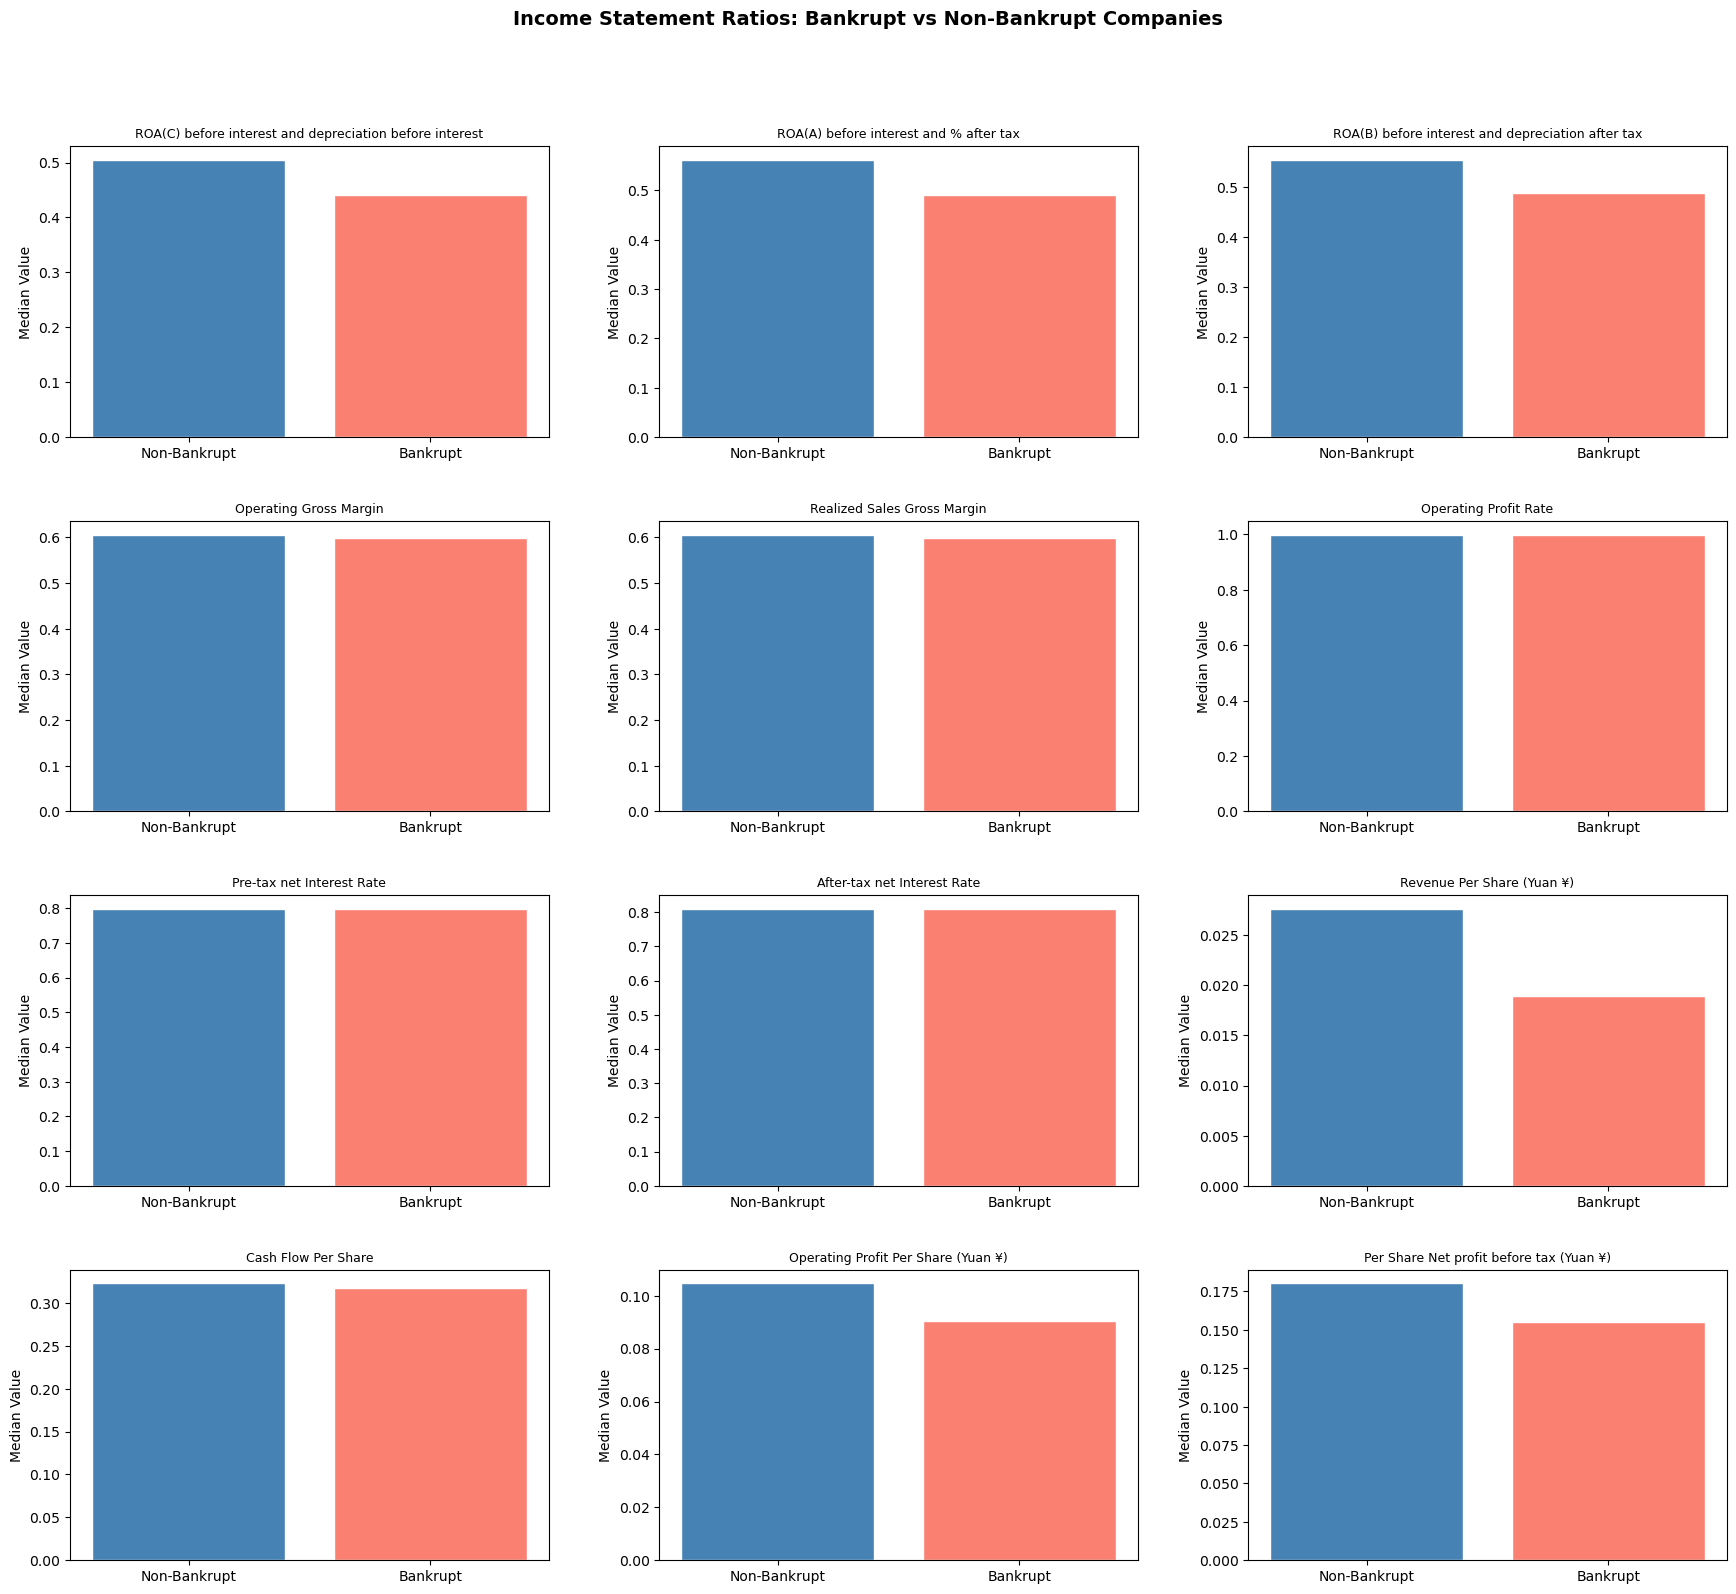

In [202]:
fig, ax = plt.subplots(4, 3, figsize=(18, 16))
ax = ax.flatten()
fig.suptitle('Income Statement Ratios: Bankrupt vs Non-Bankrupt Companies',fontsize=14, fontweight='bold', y=1.01)

for i,col in enumerate(income_ratios):
    median = [non_bankrupt[col].median(), bankrupt[col].median()]
    ax[i].bar(['Non-Bankrupt',"Bankrupt"],median,color=['steelblue', 'salmon'], edgecolor='white')
    ax[i].set_title(col.strip(), fontsize=9)
    ax[i].set_ylabel('Median Value')
plt.tight_layout(pad=3.0)
plt.savefig("charts/03_income_statement_ratios.png", dpi=150, bbox_inches='tight')
plt.show()

### Key Observations — Income Statement Ratios

- **ROA (A, B, C):** Bankrupt companies show lower return on assets across all three variants — indicating weaker profitability before and after tax
- **Revenue Per Share:** Bankrupt companies generate significantly less revenue per share (~0.018 vs ~0.025) — a clear sign of weaker business performance
- **Operating & Realized Gross Margin:** Surprisingly similar between both groups — gross margin alone is not a strong bankruptcy predictor
- **Operating Profit Rate:** Almost identical — operating efficiency does not clearly distinguish bankrupt from healthy companies
- **Pre-tax & After-tax Net Interest Rate:** Slightly lower for bankrupt companies — less earnings available to service debt
- **Cash Flow Per Share:** Bankrupt companies show higher median — driven by outliers, not representative of true cash generation
- **Key Insight:** Income statement ratios alone show subtle differences — this is why machine learning across all
  

### 3.2.2 Balance_Sheet_Ratios

In [203]:
balance_sheet_ratios = [
    ' Current Ratio',
    ' Quick Ratio',
    ' Debt ratio %',
    ' Net worth/Assets',
    ' Borrowing dependency',
    ' Long-term fund suitability ratio (A)',
    ' Current Liability to Assets',
    ' Working Capital to Total Assets',
    ' Quick Assets/Total Assets',
    ' Current Assets/Total Assets',
    ' Cash/Total Assets',
    ' Retained Earnings to Total Assets',
    ' Equity to Liability',
    ' Liability to Equity',
    ' Total debt/Total net worth']

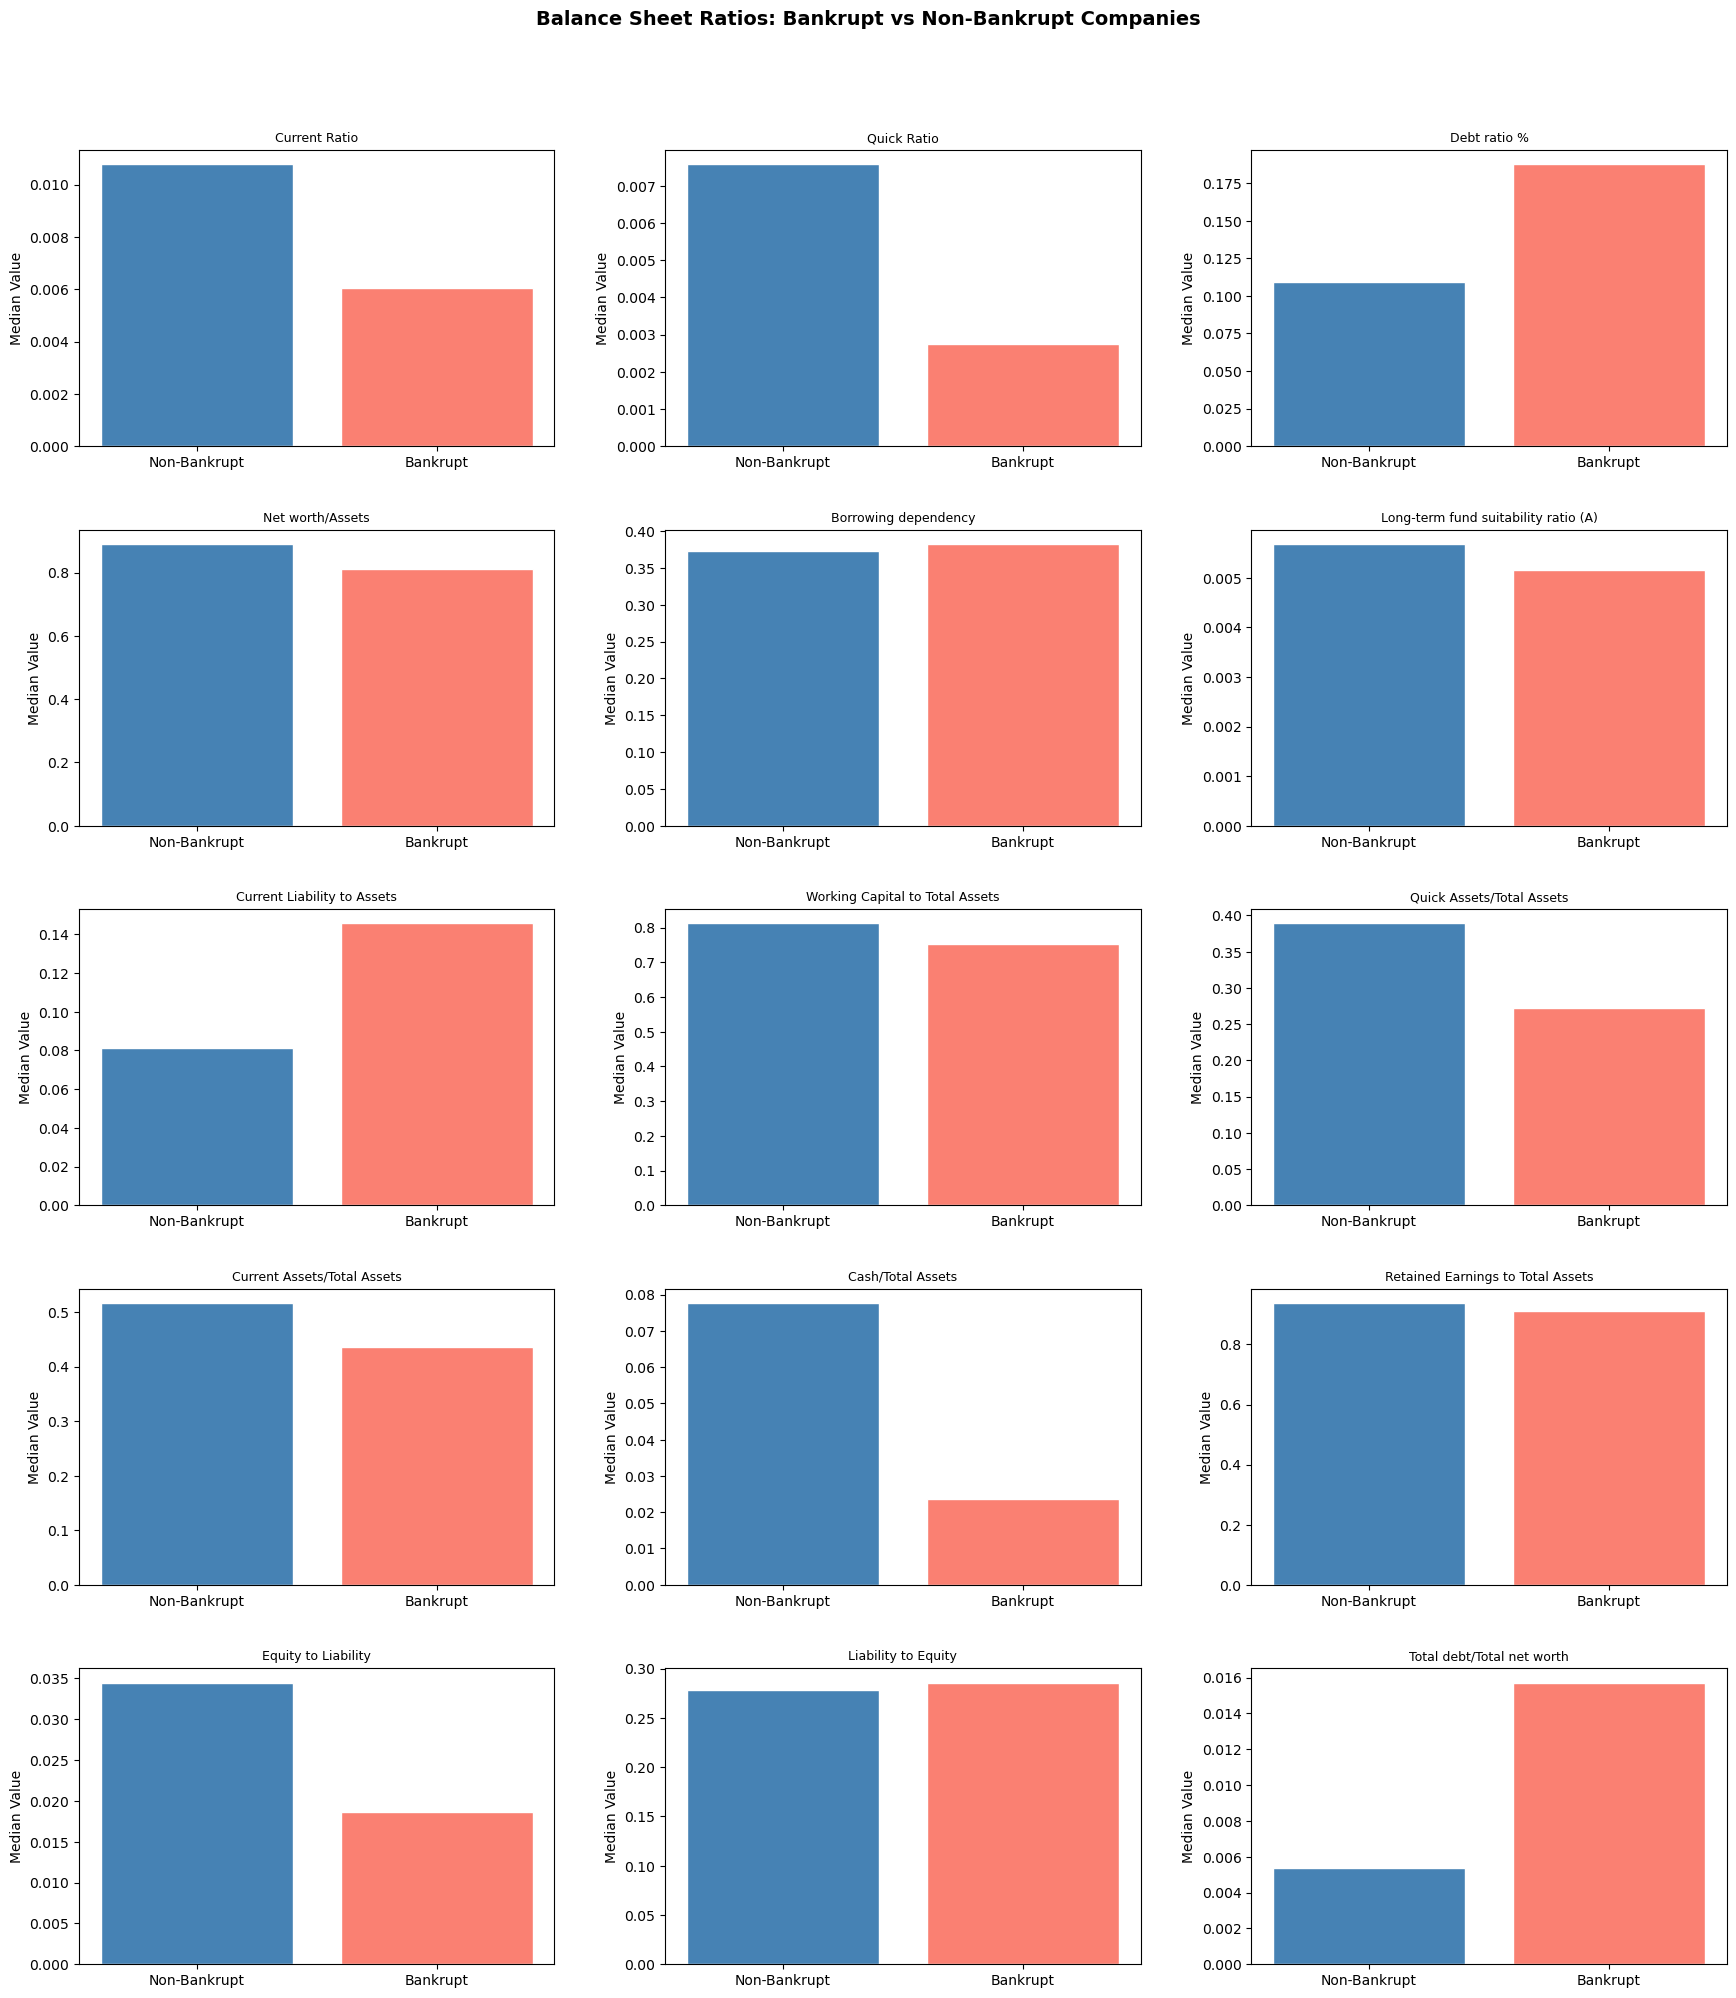

In [204]:
fig, ax = plt.subplots(5, 3, figsize=(18, 20))
ax = ax.flatten()
fig.suptitle('Balance Sheet Ratios: Bankrupt vs Non-Bankrupt Companies', 
             fontsize=14, fontweight='bold', y=1.01)

for i, col in enumerate(balance_sheet_ratios):
    median = [non_bankrupt[col].median(), bankrupt[col].median()]
    ax[i].bar(['Non-Bankrupt', 'Bankrupt'], median,
              color=['steelblue', 'salmon'], edgecolor='white')
    ax[i].set_title(col.strip(), fontsize=9)
    ax[i].set_ylabel('Median Value')

plt.tight_layout(pad=3.0)
plt.savefig("charts/04_balance_sheet_ratios.png", dpi=150, bbox_inches='tight')
plt.show()

### Key Observations — Balance Sheet Ratios
Unlike income statement ratios which showed subtle differences, balance sheet ratios reveal clear and meaningful separation between bankrupt and non-bankrupt companies.
- **Current Ratio & Quick Ratio:** Non-bankrupt companies have significantly higher liquidity ratios — they can cover short-term obligations. Bankrupt companies show dangerously low liquidity, a classic early warning sign of financial distress.
- **Debt Ratio %:** Bankrupt companies carry nearly double the debt ratio (~0.175 vs ~0.10) — excessive leverage is a primary driver of bankruptcy.
- **Net Worth/Assets:** Non-bankrupt companies have higher equity backing (~0.82 vs ~0.79) — bankrupt companies rely more on debt than equity to finance assets.
- **Current Liability to Assets:** Bankrupt companies show significantly higher current liabilities relative to assets (~0.14 vs ~0.08) — short-term debt pressure is a strong bankruptcy signal.
- **Working Capital to Total Assets:** Similar between both groups — working capital alone is not a strong differentiator.
- **Quick Assets/Total Assets & Cash/Total Assets:** Non-bankrupt companies hold more liquid assets — bankrupt companies have fewer resources to meet unexpected obligations.
- **Retained Earnings to Total Assets:** Non-bankrupt companies have significantly higher retained earnings (~0.90 vs ~0.82) — bankrupt companies have eroded their earnings base over time.
- **Equity to Liability:** Non-bankrupt companies show higher equity relative to liabilities — bankrupt companies are more leveraged.
- **Total Debt/Total Net Worth:** Bankrupt companies show significantly higher ratio (~0.016 vs ~0.006) — debt far exceeds net worth, a critical solvency warning.
- **Key Insight:** Liquidity and leverage ratios are the strongest predictors of bankruptcy — consistent with Altman Z-Score theory which heavily weights these same metrics.

In [205]:
cashflow_ratios = [
    ' Cash flow rate',
    ' Cash Flow Per Share',
    ' Cash Reinvestment %',
    ' Cash/Current Liability',
    ' Cash Flow to Liability',
    ' CFO to Assets',
    ' Cash Flow to Equity',
    ' Cash Flow to Total Assets',
    ' Cash Flow to Sales',
    ' Cash/Total Assets',
    ' Operating Funds to Liability',
    ' Quick Assets/Current Liability',
    ' Cash Turnover Rate',
    ' Current Liability to Current Assets',
    ' Net Income to Total Assets']

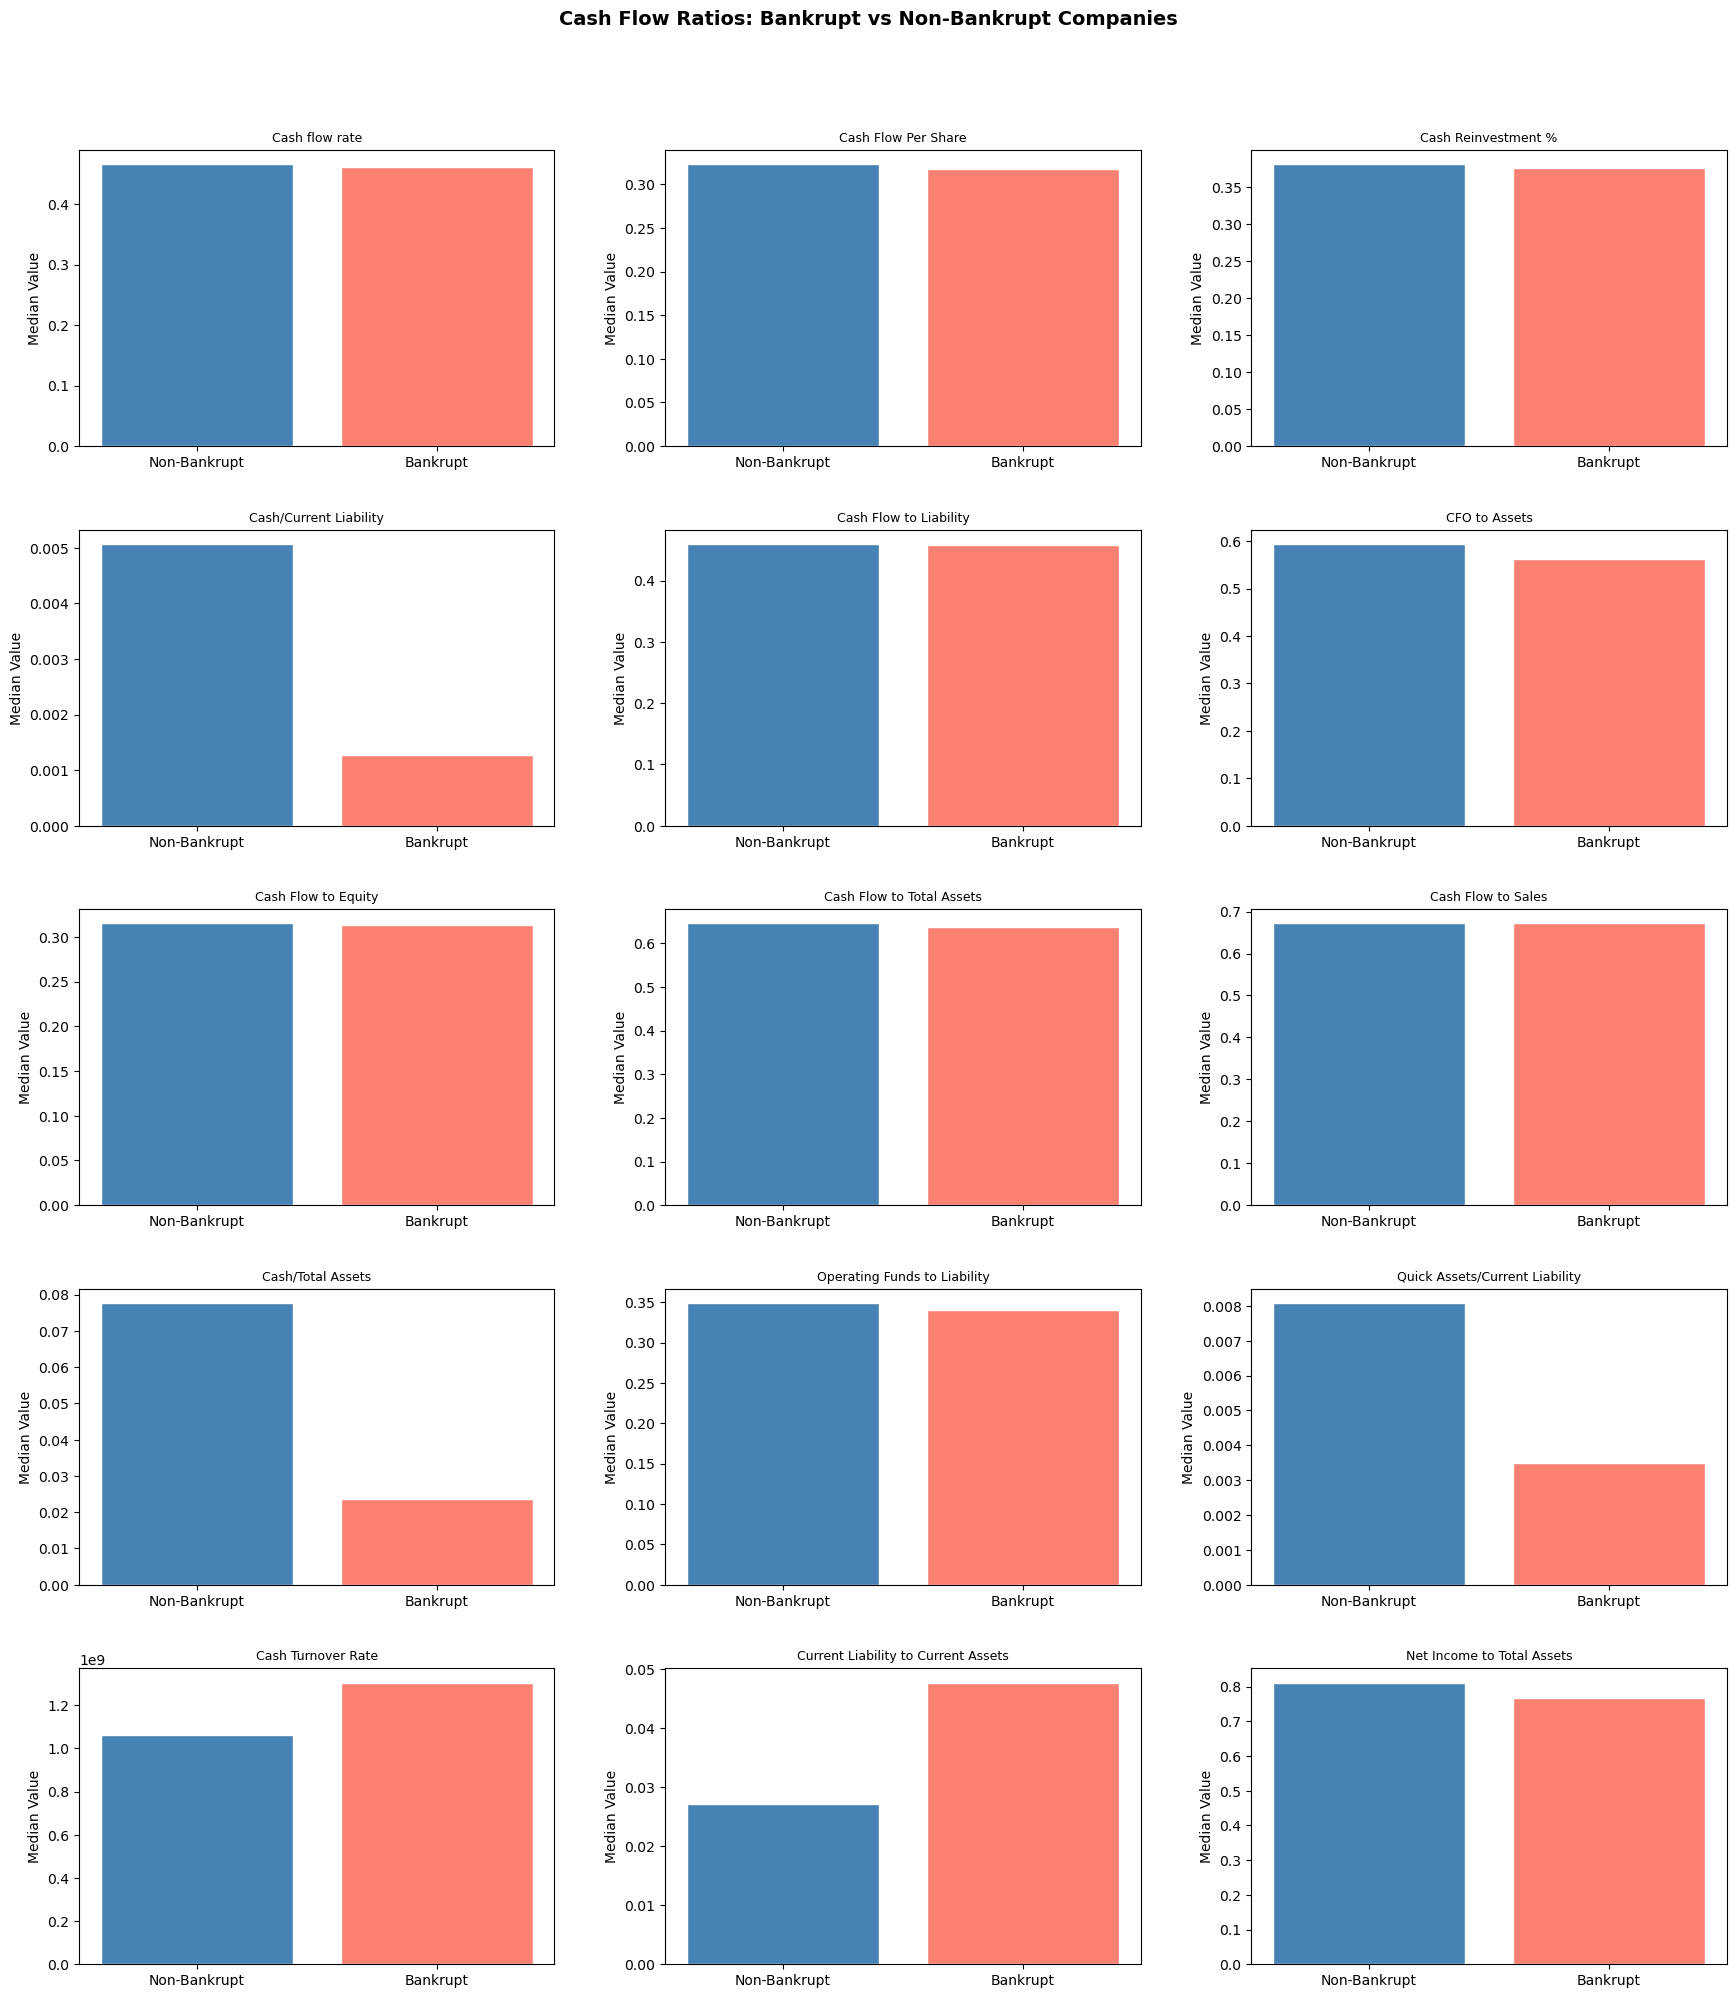

In [206]:
fig, ax = plt.subplots(5, 3, figsize=(18, 20))
ax = ax.flatten()
fig.suptitle('Cash Flow Ratios: Bankrupt vs Non-Bankrupt Companies', 
             fontsize=14, fontweight='bold', y=1.01)

for i, col in enumerate(cashflow_ratios):
    median = [non_bankrupt[col].median(), bankrupt[col].median()]
    ax[i].bar(['Non-Bankrupt', 'Bankrupt'], median,
              color=['steelblue', 'salmon'], edgecolor='white')
    ax[i].set_title(col.strip(), fontsize=9)
    ax[i].set_ylabel('Median Value')

plt.tight_layout(pad=3.0)
plt.savefig("charts/05_cashflow_ratios.png", dpi=150, bbox_inches='tight')
plt.show()

### Key Observations — Cash Flow Ratios

- **Cash Flow Rate & Cash Flow Per Share:** Almost identical between both groups — operating cash generation alone does not distinguish bankrupt from healthy companies
- **Cash Reinvestment %:** Similar across both groups — reinvestment patterns are not a strong bankruptcy signal
- **Cash/Current Liability:** Non-bankrupt companies show significantly higher ratio (~0.005 vs ~0.001) — bankrupt companies have very little cash relative to short-term obligations, a critical liquidity warning
- **Cash Flow to Liability:** Nearly identical — total cash flow relative to liabilities does not clearly separate the two groups
- **CFO to Assets:** Non-bankrupt companies slightly higher — better operational cash generation relative to asset base
- **Cash/Total Assets:** Non-bankrupt companies hold significantly more cash relative to total assets (~0.075 vs ~0.025) — bankrupt companies are cash-starved
- **Quick Assets/Current Liability:** Non-bankrupt companies significantly higher (~0.008 vs ~0.0035) — bankrupt companies cannot quickly convert assets to meet current obligations
- **Cash Turnover Rate:** Bankrupt companies show higher cash turnover — contains extreme outliers (note 1e9 scale on y-axis), median may be distorted, this feature requires outlier treatment before modeling
- **Current Liability to Current Assets:** Bankrupt companies significantly higher (~0.045 vs ~0.027) — current liabilities exceed current assets, a classic insolvency signal
- **Net Income to Total Assets:** Non-bankrupt companies slightly higher — better overall return on assets
- **Key Insight:** Cash liquidity ratios — especially Cash/Current Liability and Quick Assets/Current Liability — are the strongest cash flow signals of bankruptcy

# 4. Preprocessing

No missing values found across all 96 columns — no imputation required.

In [207]:
f.dtypes

Bankrupt?                                                     int64
 ROA(C) before interest and depreciation before interest    float64
 ROA(A) before interest and % after tax                     float64
 ROA(B) before interest and depreciation after tax          float64
 Operating Gross Margin                                     float64
                                                             ...   
 Liability to Equity                                        float64
 Degree of Financial Leverage (DFL)                         float64
 Interest Coverage Ratio (Interest expense to EBIT)         float64
 Net Income Flag                                              int64
 Equity to Liability                                        float64
Length: 96, dtype: object

In [208]:
obj = f.select_dtypes(include = "object").columns.tolist()
obj

[]

 No encoding needed — all 96 features are numerical no categorical variables

In [209]:
print(f.drop(columns=['Bankrupt?']).min().min())
f.drop(columns=['Bankrupt?']).max().max()

0.0


10000000000.0

Scaling needed for Logistic Regression while most features are 0–1 some contain extreme outliers (max value = 10 billion)StandardScaler will be applied inside the pipeline for Logistic Regression only

In [210]:
f[" Net Income Flag"].value_counts()

 Net Income Flag
1    6819
Name: count, dtype: int64

Net Income Flag constant value of 1 across all 6,819 rows ,zero variance ,provides no predictive information to the model

## 4.1 Train_Test Split

In [211]:
from sklearn.model_selection import train_test_split

In [212]:
x = f.drop(["Bankrupt?"," Net Income Flag"],axis=1)

In [213]:
y = f["Bankrupt?"]

In [214]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 42 , stratify = y)

# 5. Modelling

In [215]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score

**Why These Three Models:**
- Logistic Regression : selected as a baseline to confirm the non linearity hypothesis, EDA showed weak linear correlations (max = 0.32), so we expect this model to underfit and serve as a lower bound for performance
  
- LightGBM & XGBoost — selected as the primary models to capture non-linear relationships between financial ratios and bankruptcy Both handle class imbalance and tabular data well, However overfitting is a known risk with gradient boosting on small datasets (6,819 rows, 94 features) — train vs test score gap will be monitored closely

Primary metric: AUC — accuracy is misleading with 96.8% negative class. AUC measures the model's ability to rank bankrupt companies above healthy ones regardless of threshold.

In [216]:
models = {
    'LGBMClassifier': LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    'XGBClassifier': XGBClassifier(scale_pos_weight=30, random_state=42, n_jobs=-1),
    'LogisticRegression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)}

In [217]:
results = []
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()),
                    ("model", model)])
    pipe.fit(x_train, y_train)
    cv = cross_val_score(pipe, x_train, y_train, cv=5, scoring="roc_auc").mean()
    y_pred = pipe.predict(x_test)
    y_prob = pipe.predict_proba(x_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    print(f"Name: {name}, Train Score: {pipe.score(x_train, y_train):.4f}, CV AUC: {cv:.4f}, Test AUC: {test_auc:.4f}")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

Name: LGBMClassifier, Train Score: 1.0000, CV AUC: 0.9340, Test AUC: 0.9507
Name: XGBClassifier, Train Score: 1.0000, CV AUC: 0.9238, Test AUC: 0.9452
Name: LogisticRegression, Train Score: 0.8794, CV AUC: 0.8739, Test AUC: 0.9171


**Results confirm our pre-training hypothesis:**

- **LightGBM & XGBoost** — Train score of 1.0 confirms overfitting as predicted. However, Test AUC of 0.95+ shows the models still generalize well to unseen data — the overfitting did not severely hurt performance
- **Logistic Regression** — Underfitting confirmed (Train Score 0.88) as predicted due to weak linear relationships. However, Test AUC 0.9171 is surprisingly strong — better than expected
- **LightGBM selected as final model** — highest Test AUC (0.9507) and CV AUC (0.9340)
- **Next step:** Hyperparameter tuning to reduce overfitting in LightGBM while maintaining high test AUC

# 6. Tune

#### RandomizedSearchCV

In [218]:
from sklearn.model_selection import RandomizedSearchCV

In [219]:
params = {'model__max_depth':[3,5,7],
          'model__num_leaves':[15,31,50],
          'model__min_child_samples':[20,50,100],
          'model__learning_rate':[0.05,0.1,0.15]}

In [220]:
tune_pipe = Pipeline([("model", LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1))])

In [221]:
tune_I = RandomizedSearchCV(tune_pipe,params,n_iter=20,cv=5,scoring="roc_auc",random_state=42,n_jobs=-1)

In [222]:
tune_I.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.05, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_samples': [20, 50, ...], 'model__num_leaves': [15, 31, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [223]:
print(f"Best CV AUC: {tune_I.best_score_:.4f}")
print(f"Best params: {tune_I.best_params_}")

Best CV AUC: 0.9355
Best params: {'model__num_leaves': 31, 'model__min_child_samples': 50, 'model__max_depth': 7, 'model__learning_rate': 0.05}


In [224]:
best_model = tune_I.best_estimator_
print(f"Train Score: {best_model.score(x_train, y_train):.4f}")
print(f"Test AUC: {roc_auc_score(y_test, best_model.predict_proba(x_test)[:, 1]):.4f}")

Train Score: 0.9797
Test AUC: 0.9512


**Key Observations:**

- Tuning successfully reduced overfitting — train score dropped from 1.0 to 0.9797
- Test AUC marginally improved from 0.9507 to 0.9512
- Some overfitting remains — this is a data size limitation (6,819 rows, 94 features) rather than a modeling error. With more data the gap would close further
- Best parameters: `max_depth=7`, `num_leaves=31`, `min_child_samples=50`, `learning_rate=0.05`

# 7. Model Results

In [225]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [226]:
y_best_pred = best_model.predict(x_test)

In [227]:
cm = confusion_matrix(y_test,y_pred)

In [228]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Bankrupt', 'Bankrupt']) 

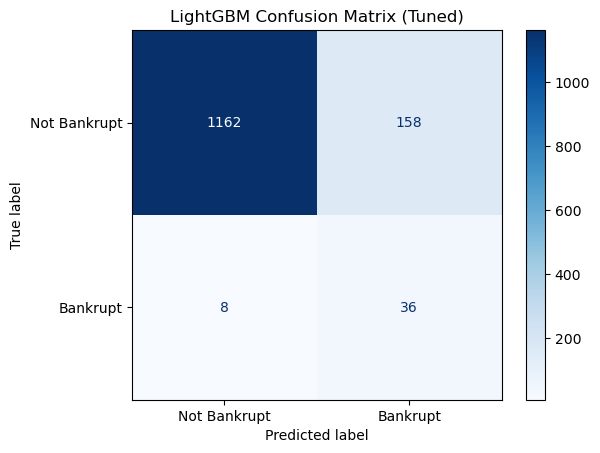

In [229]:
disp.plot(cmap="Blues")
plt.title('LightGBM Confusion Matrix (Tuned)')
plt.savefig("charts/07_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

**Key Observations:**

- **True Positives (36):** Model correctly identified 36 out of 44 bankrupt companies — 81.8% recall on the minority class
- **False Negatives (8):** Only 8 bankrupt companies were missed — critical errors in a real-world context as these companies would go undetected
- **False Positives (158):** 158 healthy companies incorrectly flagged as bankrupt — acceptable trade-off to catch more true bankruptcies
- **Precision (Bankrupt): 0.36** — of all companies predicted bankrupt, only 36% actually were. Low but expected with severe class imbalance
- **Recall (Bankrupt): 0.66** — model catches 66% of actual bankruptcies
- **Key Insight:** In bankruptcy prediction, recall is more important than precision — missing a bankrupt company (false negative) is far more costly than a false alarm (false positive). The model prioritizes catching bankruptcies over precision.

In [230]:
print(classification_report(y_test, y_best_pred, target_names=['Not Bankrupt', 'Bankrupt']))

              precision    recall  f1-score   support

Not Bankrupt       0.99      0.96      0.97      1320
    Bankrupt       0.36      0.66      0.47        44

    accuracy                           0.95      1364
   macro avg       0.68      0.81      0.72      1364
weighted avg       0.97      0.95      0.96      1364



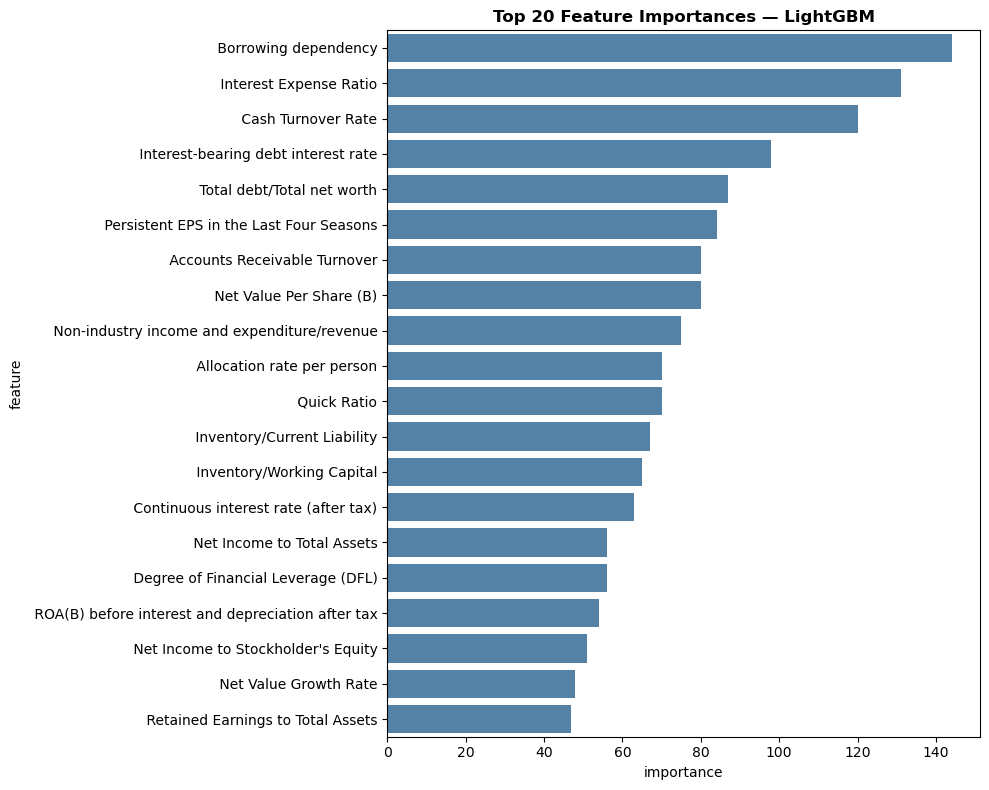

In [231]:
lgbm_model = best_model.named_steps["model"]
feat_imp = pd.DataFrame({"feature":x_train.columns,
                         "importance":lgbm_model.feature_importances_}).sort_values('importance', ascending=False).head(20)
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp, x='importance', y='feature', color='steelblue')
plt.title('Top 20 Feature Importances — LightGBM', fontweight='bold')
plt.tight_layout()
plt.savefig("charts/08_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

###  Feature Importance

- **Borrowing Dependency** — most important feature, confirms leverage is the primary bankruptcy driver
- **Interest Expense Ratio** — high interest burden relative to earnings is a strong bankruptcy signal
- **Cash Turnover Rate** — despite containing outliers, the model found it highly predictive
- **Interest-bearing Debt Interest Rate** — cost of debt is a key differentiator
- **Total Debt/Total Net Worth** — leverage ratio confirmed as top predictor, consistent with EDA findings
- **Persistent EPS & Net Value Per Share** — earnings stability over time matters more than single-period profitability
- **Quick Ratio & Net Income to Total Assets** — liquidity and profitability both feature in top 20

In [232]:
import joblib
import os

In [233]:
os.makedirs("bankruptcy_model/trained_models", exist_ok=True)
joblib.dump(best_model, "bankruptcy_model/trained_models/lgbm_pipeline.pkl")
print("Model saved successfully")

Model saved successfully
